In [10]:
from tied import TIEDModel
from transformers import AutoTokenizer
import torch
import matplotlib.pyplot as plt

In [49]:
# Load model and tokenizer
# checkpoint-66000
# models/checkpoint-2000
name = "models/checkpoint-1000"
model = TIEDModel.from_pretrained(name).to("cuda")
tokenizer = AutoTokenizer.from_pretrained(name)
model.eval()
print("")

[Init] in_channels=4, hidden_size=2048, image_size=256, latent_stride=8, input_size=32, num_blocks=3, bot_hw=4, bot_ch=128, flat_dim=2048
[Down 0] 4x32x32 -> 32x16x16
[Down 1] 32x16x16 -> 64x8x8
[Down 2] 64x8x8 -> 128x4x4
[Mid] 128x4x4 = 2048
[Up 0] 128x4x4 -> 64x8x8
[Up 1] 64x8x8 -> 32x16x16
[Up 2] 32x16x16 -> 4x32x32
[FC mu] 2048 -> 2048
[FC logvar] 2048 -> 2048
[FC seed] 2048 -> 2048
[Conv out] 4 -> 4 at 32x32



In [50]:
from torchvision.transforms import GaussianBlur


def generate_image(model, prompt, device="cuda"):
    blur = GaussianBlur(kernel_size=5, sigma=0.2)

    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask

    generated_latents = model(input_ids=input_ids, attention_mask=attention_mask).encoded_latents
    # generated_latents = blur(generated_latents)  # Apply Gaussian blur to the latents
    decoded = model.vae.decode(generated_latents).sample  # [B, 3, H, W]
    decoded = (decoded / 2 + 0.5).clamp(0, 1)

    img_np = decoded.squeeze().permute(1, 2, 0).detach().cpu().numpy()

    plt.imshow(img_np)
    plt.axis('off')
    plt.savefig("output_image.png", bbox_inches='tight', pad_inches=0)
    plt.show()

    return generated_latents


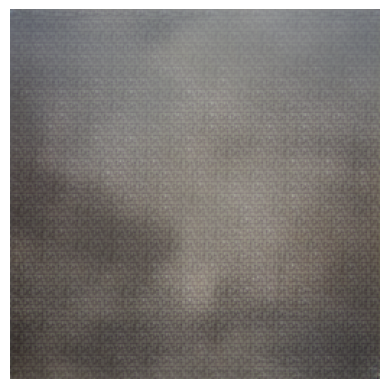

In [ ]:

prompt = """The image shows a painting of an young woman in a blue dress, dark background"""
# prompt = """The image shows a painting of a field with a few plants in the foreground and a body of water in the background"""
# prompt = """The image shows a painting of a male in a black suit, green background."""
# prompt = """The image shows a painting of a storm in the sea, dark clouds, and a dark blue sea, sunset Aivazovsky style,"""
# prompt = """The image shows a painting of a green forest, green trees in the foreground,"""
# prompt = """The image shows a painting: bright white background, dark black circle"""


generated_latents = generate_image(model, prompt)


In [70]:
import torch
import torch.nn.functional as F

def sharpen(tensor, weight=1.0):
    # tensor shape: [B, C, H, W]
    kernel = torch.tensor([[-1., -1., -1.],
                           [-1.,  9., -1.],
                           [-1., -1., -1.]], device=tensor.device).unsqueeze(0).unsqueeze(0)
    channels = tensor.shape[1]
    kernel = kernel.repeat(channels, 1, 1, 1)  # [C, 1, 3, 3]

    sharp = F.conv2d(tensor, kernel, padding=1, groups=channels)
    return tensor + weight * (sharp - tensor)

In [288]:
import torch
from PIL import Image
from torchvision import transforms
from diffusers.models import AutoencoderKL
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
vae = AutoencoderKL.from_pretrained("stabilityai/sdxl-vae").to(device)

model.vae = vae

In [42]:
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import pandas as pd
import piq
import lpips

device = "cuda" if torch.cuda.is_available() else "cpu"

input_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

lpips_fn = lpips.LPIPS(net='vgg').to(device).eval()


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /home/ubuntu/TIED/.venv/lib/python3.10/site-packages/lpips/weights/v0.1/vgg.pth


In [43]:
image = Image.open("ergaster.jpeg").convert("RGB")
# image = Image.open("blue.jpg").convert("RGB")
# image = Image.open("face.jpg").convert("RGB")
# image = Image.open("landscape.jpg").convert("RGB")
image = Image.open("body_of_water.jpg").convert("RGB")
# image = Image.open("Brad-Pitt.png").convert("RGB")
# image = Image.open("biomike.jpeg").convert("RGB")

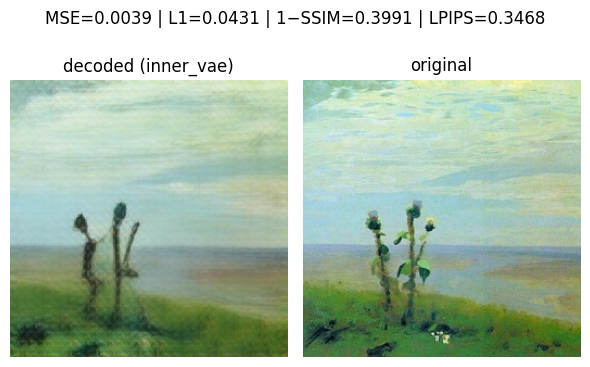

In [44]:

x = input_transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    encoded = model.vae.encode(x).latent_dist.sample()
    u, encoded_1, mu, logvar, z = model.inner_vae(encoded)
    # encoded_1 = model.inner_vae.decode(mu)
    decoded_1 = model.vae.decode(encoded_1).sample
    decoded = model.vae.decode(encoded).sample


decoded_1 = ((decoded_1 + 1) / 2).clamp(0, 1)
orig = ((x + 1) / 2).clamp(0, 1)
# orig = ((decoded + 1) / 2).clamp(0, 1)


def image_pair_losses(a, b):
    if a.dim() == 3:
        a = a.unsqueeze(0)
    if b.dim() == 3:
        b = b.unsqueeze(0)
    mse = F.mse_loss(a, b, reduction="mean").item()
    l1 = F.l1_loss(a, b, reduction="mean").item()
    ssim = piq.ssim(a, b, data_range=1.0).item()
    lp = lpips_fn(a * 2 - 1, b * 2 - 1).mean().item()
    return {"MSE": mse, "L1": l1, "1-SSIM": 1.0 - ssim, "LPIPS": lp}

metrics = image_pair_losses(decoded_1, orig)

img_dec = decoded_1.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
img_org = orig.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()

fig, axs = plt.subplots(1, 2, figsize=(6, 4))
axs[0].imshow(img_dec)
axs[0].set_title("decoded (inner_vae)")
axs[0].axis('off')
axs[1].imshow(img_org)
axs[1].set_title("original")
axs[1].axis('off')
fig.suptitle(
    f"MSE={metrics['MSE']:.4f} | L1={metrics['L1']:.4f} | 1−SSIM={metrics['1-SSIM']:.4f} | LPIPS={metrics['LPIPS']:.4f}",
    y=0.98
)
plt.tight_layout()
plt.show()

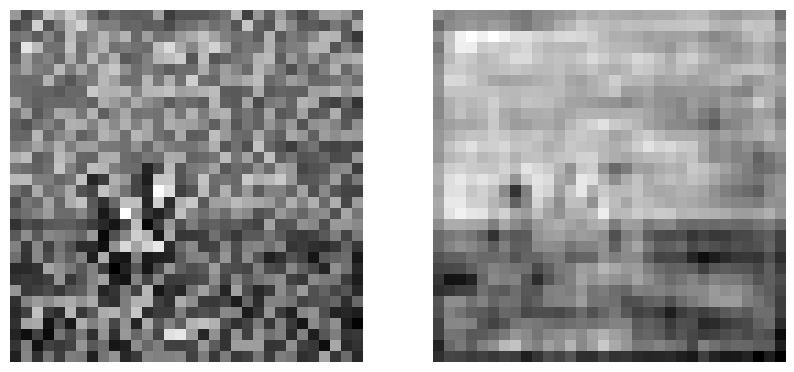

In [9]:
import matplotlib.pyplot as plt

img = encoded.squeeze(0).mean(dim=0).cpu()  # [4, 64, 64] -> [64, 64]
img_1 = encoded_1.squeeze(0).mean(dim=0).cpu()  # [4, 64, 64] -> [64, 64]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(img_1, cmap='gray')
plt.axis('off')
plt.show()


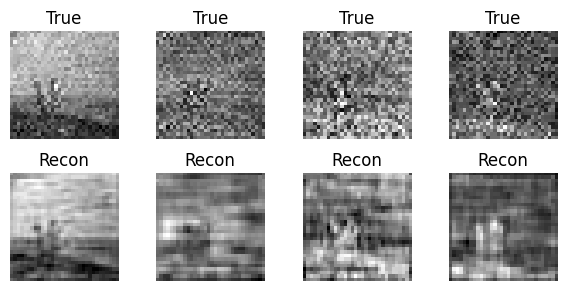

In [12]:
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import GaussianBlur

encoded_1_m = encoded.squeeze(0).cpu()  # [4, 64, 64]
encoded_2_m = encoded_1.squeeze(0).cpu()  # [4, 64, 64]

fig, axs = plt.subplots(2, 4, figsize=(6, 3))

for i in range(4):
    ch1 = encoded_1_m[i]
    ch2 = encoded_2_m[i]
    
    axs[0, i].imshow(ch1, cmap='gray')
    axs[0, i].axis('off')
    axs[0, i].set_title(f"True")
    
    axs[1, i].imshow(ch2, cmap='gray')
    axs[1, i].axis('off')
    axs[1, i].set_title(f"Recon")

plt.tight_layout()
plt.show()
